# XGBoost: Credit Risk Scoring & Credit Limit Prediction

**Objective:** Classify customer risk and predict credit limits
- **Task 1:** Risk Classification (High/Low)
- **Task 2:** Credit Limit Regression (USD amount)

In [90]:
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, ConfusionMatrixDisplay
from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('outputs', exist_ok=True)

## Dataset Generation

In [91]:
def generate_erbil_warehouse_dataset(n_samples=1000):
    rng = np.random.default_rng(42)
    
    # 1. تەمەنی دوکان یان کڕیار بە ساڵ (1 بۆ 20 ساڵ)
    shop_age_years = rng.integers(1, 21, size=n_samples)
    
    # 2. کۆی گشتی پسوولەکان لای کۆگاکەمان
    total_invoices = rng.integers(5, 500, size=n_samples)
    
    # 3. تێکڕای بەهای هەر پسوولەیەک (بە دۆلار: 200$ تا 15,000$)
    avg_invoice_value = rng.uniform(200, 15000, size=n_samples).round(-1)
    
    # 4. ژمارەی ئەو پسوولانەی پارەیان نەدراوە (قەرز)
    unpaid_invoices_count = rng.integers(0, 15, size=n_samples)
    # دڵنیابوونەوە لەوەی پسوولەی نەدراو لە کۆی پسوولەکان زیاتر نەبێت
    unpaid_invoices_count = np.minimum(unpaid_invoices_count, total_invoices)
    
    # 5. بڕی قەرزی ئێستا (دەگۆڕێت بەپێی ژمارەی پسوولە نەدراوەکان)
    current_debt = (unpaid_invoices_count * avg_invoice_value * rng.uniform(0.6, 1.2, size=n_samples)).round(-1)
    
    # 6. مێژووی دواکەوتنی پارەدان (بەپێی یاسای Poisson Distribution)
    late_payment_history = rng.poisson(lam=1.5, size=n_samples)
    
    # --- لۆژیکی زانستی بۆ Risk Score ---
    # مەترسی ڕاستەوانە دەگۆڕێت لەگەڵ ڕێژەی قەرز، وە پێچەوانە دەگۆڕێت لەگەڵ تەمەنی دوکانەکە
    debt_ratio = np.where(total_invoices > 0, unpaid_invoices_count / total_invoices, 0)
    
    risk_logit = (-2.5 
                  + 6.0 * debt_ratio 
                  + 0.8 * late_payment_history 
                  - 0.15 * shop_age_years 
                  - 0.002 * total_invoices 
                  + rng.normal(0, 0.4, n_samples))
    
    # بەکارهێنانی Sigmoid بۆ گۆڕینی لۆجیتەکە بۆ ئەگەری نێوان 0 و 1
    risk_prob = 1 / (1 + np.exp(-risk_logit))
    high_risk = (rng.uniform(size=n_samples) < risk_prob).astype(int)
    
    # --- لۆژیکی Credit Limit ---
    # لیمیتەکە لەسەر بنەمای بەهای پسوولەکان دەدرێت، بەڵام قەرز و مەترسی کەمی دەکەنەوە
    risk_multiplier = np.where(high_risk == 1, 0.3, 1.2)
    base_limit = (avg_invoice_value * 8) + (shop_age_years * 500)
    
    credit_limit = (base_limit * risk_multiplier) - (current_debt * 0.4) + rng.normal(0, 500, n_samples)
    credit_limit = np.clip(credit_limit, 500, 100000).round(-2) # نابێت لە 500$ کەمتر بێت
    
    return pd.DataFrame({
        'Shop_Age_Years': shop_age_years,
        'Total_Invoices': total_invoices,
        'Average_Invoice_Value': avg_invoice_value,
        'Unpaid_Invoices_Count': unpaid_invoices_count,
        'Current_Debt': current_debt,
        'Late_Payment_History': late_payment_history,
        'High_Risk': high_risk,
        'Credit_Limit': credit_limit,
    })

df = generate_erbil_warehouse_dataset(1000)
df.to_csv('outputs/erbil_warehouse_dataset.csv', index=False)
print(f'Dataset: {df.shape} | Class: {dict(df["High_Risk"].value_counts())}')

Dataset: (1000, 8) | Class: {0: np.int64(892), 1: np.int64(108)}


## Preprocessing & Split

In [92]:
# دیاریکردنی تایبەتمەندییە نوێیەکان بۆ ڕاهێنان (Features)
X = df[['Shop_Age_Years', 'Total_Invoices', 'Average_Invoice_Value', 
        'Unpaid_Invoices_Count', 'Current_Debt', 'Late_Payment_History']].values

# دیاریکردنی ئامانجەکان (Targets)
y_risk = df['High_Risk'].values
y_credit = df['Credit_Limit'].values

# دابەشکردنی داتاکە بۆ ڕاهێنان و تاقیکردنەوە (80% بۆ ڕاهێنان، 20% بۆ تاقیکردنەوە)
X_train, X_test, y_risk_train, y_risk_test, y_credit_train, y_credit_test = train_test_split(
    X, y_risk, y_credit, test_size=0.20, random_state=42, stratify=y_risk)

# پێوانەکردنی داتاکان (Scaling) بۆ ئەوەی جیاوازی زۆر لە نێوان ژمارەکان کاریگەری نەرێنی دروست نەکات
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training

In [93]:
# خانەی 6: ڕێکخستنی کۆتایی مۆدێلەکان بۆ نەهێشتنی Overfitting لە داتاسێتی کۆگا
xgb_clf = XGBClassifier(
    n_estimators=100,         # کەمکردنەوەی ژمارەی دارەکان بۆ ڕێگری لە لەبەرکردنی زیادە
    learning_rate=0.05,       # خێرایی فێربوونی لەسەرخۆتر
    max_depth=3,              # دابەزاندنی قووڵایی بۆ 3 (زۆر گرنگە بۆ کەمکردنەوەی جیاوازی ROC-AUC)
    min_child_weight=3,       # دڵنیابوونەوە لەوەی هەر لقێک داتای پێویستی تێدایە
    subsample=0.7,            # بەکارهێنانی 70%ی داتاکە لە هەر هەنگاوێکدا
    colsample_bytree=0.7,
    gamma=0.3,                # بەرزکردنەوەی گاما بۆ بڕینەوەی لقە بێسوودەکان
    lambda_=2.0,              # بەهێزکردنی L2 Regularization
    alpha=0.5,                # بەهێزکردنی L1 Regularization
    random_state=42, 
    verbosity=0
)
xgb_clf.fit(X_train_scaled, y_risk_train)

xgb_reg = XGBRegressor(
    n_estimators=120,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=3,
    subsample=0.7,
    colsample_bytree=0.7,
    gamma=0.3,
    lambda_=3.0,              # ڕێگری توندتر بۆ مۆدێلی ژمارەیی
    alpha=1.0,
    random_state=42, 
    verbosity=0
)
xgb_reg.fit(X_train_scaled, y_credit_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Results

In [94]:
y_risk_pred = xgb_clf.predict(X_test_scaled)
y_risk_proba = xgb_clf.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_risk_test, y_risk_pred)
prec = precision_score(y_risk_test, y_risk_pred)
rec = recall_score(y_risk_test, y_risk_pred)
f1 = f1_score(y_risk_test, y_risk_pred)
auc = roc_auc_score(y_risk_test, y_risk_proba)

print('CLASSIFICATION (Risk Scoring)')
print('='*40)
print(f'Accuracy : {acc:.4f} | Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f} | F1-Score : {f1:.4f}')
print(f'ROC-AUC  : {auc:.4f}\n')
print(classification_report(y_risk_test, y_risk_pred, target_names=['Low Risk', 'High Risk']))

CLASSIFICATION (Risk Scoring)
Accuracy : 0.9150 | Precision: 0.8571
Recall   : 0.2727 | F1-Score : 0.4138
ROC-AUC  : 0.9030

              precision    recall  f1-score   support

    Low Risk       0.92      0.99      0.95       178
   High Risk       0.86      0.27      0.41        22

    accuracy                           0.92       200
   macro avg       0.89      0.63      0.68       200
weighted avg       0.91      0.92      0.89       200



In [95]:
y_credit_pred = xgb_reg.predict(X_test_scaled)

mse = mean_squared_error(y_credit_test, y_credit_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_credit_test, y_credit_pred)
r2 = r2_score(y_credit_test, y_credit_pred)

print('REGRESSION (Credit Limit Prediction)')
print('='*40)
print(f'MSE  : ${mse:,.2f}')
print(f'RMSE : ${rmse:,.2f}')
print(f'MAE  : ${mae:,.2f}')
print(f'R²   : {r2:.4f}')

REGRESSION (Credit Limit Prediction)
MSE  : $255,629,338.46
RMSE : $15,988.41
MAE  : $9,873.50
R²   : 0.7786


In [96]:
# Evaluate on training set to check for overfitting
y_risk_train_pred = xgb_clf.predict(X_train_scaled)
y_risk_train_proba = xgb_clf.predict_proba(X_train_scaled)[:, 1]

train_acc = accuracy_score(y_risk_train, y_risk_train_pred)
train_f1 = f1_score(y_risk_train, y_risk_train_pred)
train_auc = roc_auc_score(y_risk_train, y_risk_train_proba)

print('TRAINING CLASSIFICATION (Risk Scoring)')
print('='*40)
print(f'Accuracy : {train_acc:.4f} | F1-Score : {train_f1:.4f}')
print(f'ROC-AUC  : {train_auc:.4f}\n')

y_credit_train_pred = xgb_reg.predict(X_train_scaled)

train_mse = mean_squared_error(y_credit_train, y_credit_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_credit_train, y_credit_train_pred)
train_r2 = r2_score(y_credit_train, y_credit_train_pred)

print('TRAINING REGRESSION (Credit Limit Prediction)')
print('='*40)
print(f'MSE  : ${train_mse:,.2f}')
print(f'RMSE : ${train_rmse:,.2f}')
print(f'MAE  : ${train_mae:,.2f}')
print(f'R²   : {train_r2:.4f}')

print('\nOVERFITTING CHECK:')
print('='*40)
print('If training metrics are significantly better than test metrics, the model may be overfitting.')
print(f'Classification - Train Acc: {train_acc:.4f} vs Test Acc: {acc:.4f} (Gap: {train_acc - acc:.4f})')
print(f'Classification - Train AUC: {train_auc:.4f} vs Test AUC: {auc:.4f} (Gap: {train_auc - auc:.4f})')
print(f'Regression - Train R²: {train_r2:.4f} vs Test R²: {r2:.4f} (Gap: {train_r2 - r2:.4f})')

TRAINING CLASSIFICATION (Risk Scoring)
Accuracy : 0.9187 | F1-Score : 0.4144
ROC-AUC  : 0.9101

TRAINING REGRESSION (Credit Limit Prediction)
MSE  : $206,002,197.01
RMSE : $14,352.78
MAE  : $8,541.04
R²   : 0.8062

OVERFITTING CHECK:
If training metrics are significantly better than test metrics, the model may be overfitting.
Classification - Train Acc: 0.9187 vs Test Acc: 0.9150 (Gap: 0.0037)
Classification - Train AUC: 0.9101 vs Test AUC: 0.9030 (Gap: 0.0071)
Regression - Train R²: 0.8062 vs Test R²: 0.7786 (Gap: 0.0276)


In [97]:
import numpy as np

def evaluate_new_customer(shop_age, total_invoices, avg_invoice_val, unpaid_count, current_debt, late_history):
    # ١. کۆکردنەوەی داتاکانی کڕیارەکە
    customer_data = np.array([[shop_age, total_invoices, avg_invoice_val, 
                               unpaid_count, current_debt, late_history]])
    
    # ٢. پێوانەکردنی داتاکە (Scaling) بە هەمان ئەو پێوەرەی لە ڕاهێناندا بەکارمان هێنا
    customer_scaled = scaler.transform(customer_data)
    
    # ٣. وەرگرتنی پێشبینییەکان لە هەردوو مۆدێلەکە
    risk_pred = xgb_clf.predict(customer_scaled)[0]
    risk_prob = xgb_clf.predict_proba(customer_scaled)[0][1] # ئەگەری مەترسی بە لەسەدا
    limit_pred = xgb_reg.predict(customer_scaled)[0]
    
    # ٤. ڕێکخستنی ئەنجامەکان بۆ خوێندنەوە
    risk_status = "بەرزە (High Risk) ⚠️" if risk_pred == 1 else "نزمە و پارێزراوە (Low Risk) ✅"
    
    print("="*45)
    print("📊 ئەنجامی هەڵسەنگاندنی کڕیاری نوێ")
    print("="*45)
    print(f"ئاستی مەترسی:        {risk_status}")
    print(f"ئەگەری مەترسی:       {risk_prob * 100:.1f}%")
    print(f"باشترین لیمیتی قەرز: ${limit_pred:,.2f}")
    print("="*45 + "\n")

# -- تاقیکردنەوەی یەکەم (کڕیارێکی جێگای متمانە و کۆن) --
# تەمەنی دوکان 10 ساڵ، 150 پسوولە، تێکڕای 2000 دۆلار، تەنها 1 پسوولەی نەدراو، 1500 قەرز، 0 دواکەوتن
print("تاقیکردنەوەی ١: کڕیارێکی باش")
evaluate_new_customer(shop_age=10, total_invoices=150, avg_invoice_val=2000, 
                      unpaid_count=1, current_debt=1500, late_history=0)

# -- تاقیکردنەوەی دووەم (کڕیارێکی نوێ و مەترسیدار) --
# تەمەنی دوکان 1 ساڵ، 10 پسوولە، تێکڕا 800 دۆلار، 6 پسوولەی نەدراو، 4500 قەرز، 3 دواکەوتن
print("تاقیکردنەوەی ٢: کڕیارێکی مەترسیدار")
evaluate_new_customer(shop_age=1, total_invoices=10, avg_invoice_val=800, 
                      unpaid_count=6, current_debt=4500, late_history=3)

تاقیکردنەوەی ١: کڕیارێکی باش
📊 ئەنجامی هەڵسەنگاندنی کڕیاری نوێ
ئاستی مەترسی:        نزمە و پارێزراوە (Low Risk) ✅
ئەگەری مەترسی:       1.9%
باشترین لیمیتی قەرز: $27,589.57

تاقیکردنەوەی ٢: کڕیارێکی مەترسیدار
📊 ئەنجامی هەڵسەنگاندنی کڕیاری نوێ
ئاستی مەترسی:        بەرزە (High Risk) ⚠️
ئەگەری مەترسی:       73.1%
باشترین لیمیتی قەرز: $-6,434.57



## Visualization

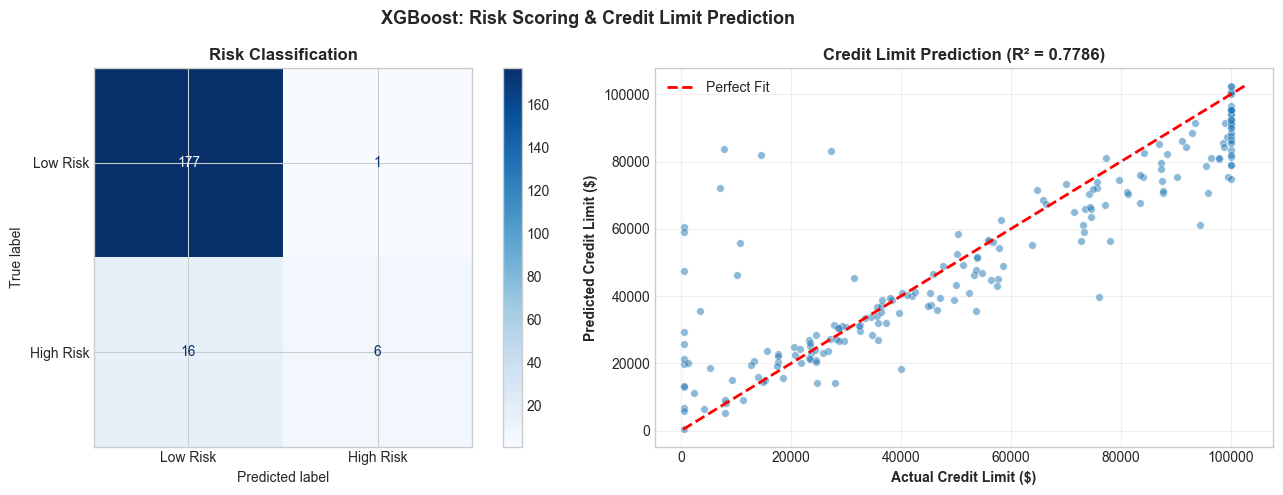

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost: Risk Scoring & Credit Limit Prediction', fontsize=13, fontweight='bold')

cm = confusion_matrix(y_risk_test, y_risk_pred)
ConfusionMatrixDisplay(cm, display_labels=['Low Risk', 'High Risk']).plot(ax=axes[0], colorbar=True, cmap='Blues')
axes[0].set_title('Risk Classification', fontweight='bold')

axes[1].scatter(y_credit_test, y_credit_pred, alpha=0.5, s=30, color='#1f77b4', edgecolors='white', linewidth=0.5)
lims = [min(y_credit_test.min(), y_credit_pred.min()), max(y_credit_test.max(), y_credit_pred.max())]
axes[1].plot(lims, lims, 'r--', lw=2, label='Perfect Fit')
axes[1].set_xlabel('Actual Credit Limit ($)', fontweight='bold')
axes[1].set_ylabel('Predicted Credit Limit ($)', fontweight='bold')
axes[1].set_title(f'Credit Limit Prediction (R² = {r2:.4f})', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/credit_risk_scoring_results.png', dpi=150, bbox_inches='tight')
plt.show()

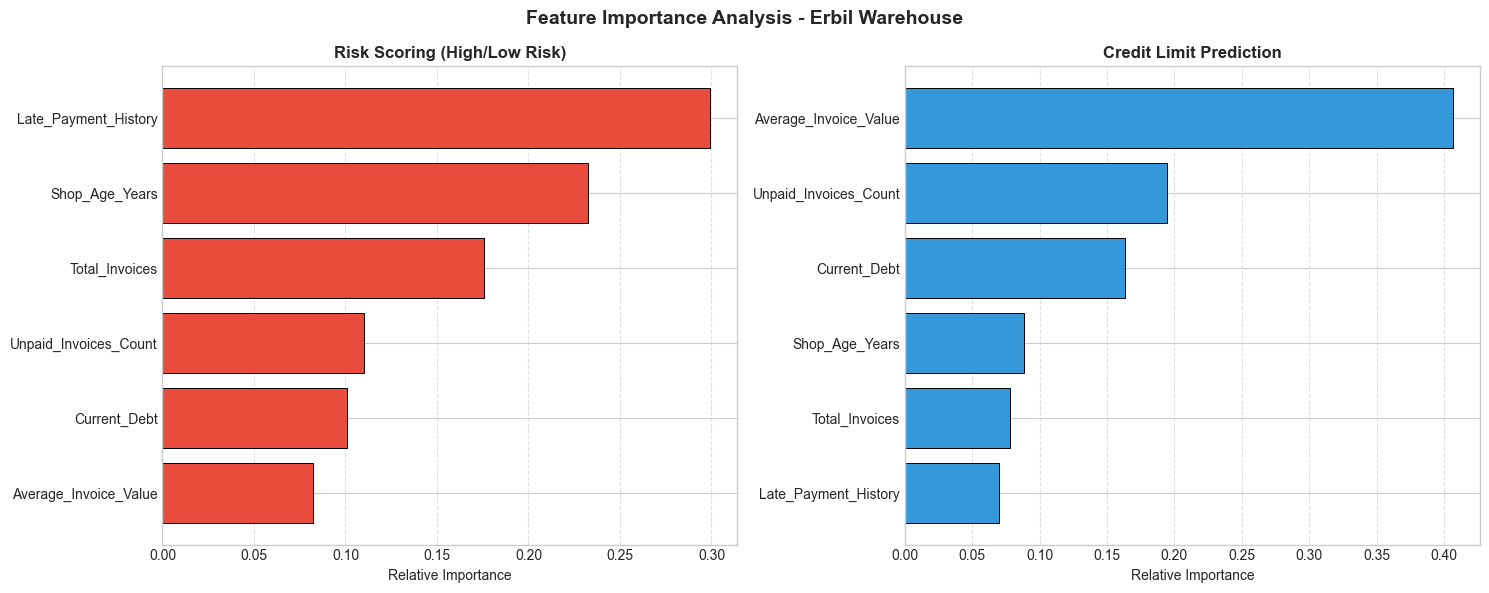

In [99]:
import pandas as pd
import matplotlib.pyplot as plt

# ناساندنی ناوی تایبەتمەندییەکان وەک ئەوەی لە داتاسێتە نوێیەکەدا هەیە
feature_names = ['Shop_Age_Years', 'Total_Invoices', 'Average_Invoice_Value', 
                 'Unpaid_Invoices_Count', 'Current_Debt', 'Late_Payment_History']

# وەرگرتنی ڕێژەی گرنگی فیچەرەکان لە هەردوو مۆدێلەکەدا
risk_importance = xgb_clf.feature_importances_
limit_importance = xgb_reg.feature_importances_

# دروستکردنی دەیتافرەیم بۆ ڕێکخستنیان بەپێی گرنگی
df_risk_imp = pd.DataFrame({'Feature': feature_names, 'Importance': risk_importance}).sort_values(by='Importance', ascending=True)
df_limit_imp = pd.DataFrame({'Feature': feature_names, 'Importance': limit_importance}).sort_values(by='Importance', ascending=True)

# کێشانی هێڵکارییەکان
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Feature Importance Analysis - Erbil Warehouse', fontsize=14, fontweight='bold')

# هێڵکاری مۆدێلی مەترسی (Risk Model)
axes[0].barh(df_risk_imp['Feature'], df_risk_imp['Importance'], color='#e74c3c', edgecolor='black', linewidth=0.7)
axes[0].set_title('Risk Scoring (High/Low Risk)', fontweight='bold')
axes[0].set_xlabel('Relative Importance')
axes[0].grid(axis='x', linestyle='--', alpha=0.6)

# هێڵکاری مۆدێلی لیمیت (Credit Limit Model)
axes[1].barh(df_limit_imp['Feature'], df_limit_imp['Importance'], color='#3498db', edgecolor='black', linewidth=0.7)
axes[1].set_title('Credit Limit Prediction', fontweight='bold')
axes[1].set_xlabel('Relative Importance')
axes[1].grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Export Results

In [100]:
results_export = pd.DataFrame({
    'Actual_Risk': y_risk_test,
    'Predicted_Risk': y_risk_pred,
    'Risk_Probability': y_risk_proba,
    'Actual_Credit_Limit': y_credit_test,
    'Predicted_Credit_Limit': y_credit_pred,
    'Prediction_Error': np.abs(y_credit_test - y_credit_pred)
})
results_export.to_csv('outputs/credit_risk_predictions.csv', index=False)

print('\nExport Complete:')
print('  • credit_risk_dataset.csv')
print('  • credit_risk_predictions.csv')
print('  • credit_risk_scoring_results.png')


Export Complete:
  • credit_risk_dataset.csv
  • credit_risk_predictions.csv
  • credit_risk_scoring_results.png


In [101]:
import joblib

# پاشەکەوتکردنی مۆدێلەکە و پاککەرەوەی داتاکە (Scaler)
# تێبینی: پێویستە ناوی گۆڕاوەکان ڕێک ئەوانە بن کە لە کۆدەکەتدا بەکارت هێناون
joblib.dump(xgb_clf, 'outputs/risk_model.joblib')
joblib.dump(xgb_reg, 'outputs/limit_model.joblib')
joblib.dump(scaler, 'outputs/scaler.joblib')

print("Models successfully saved to 'outputs' folder!")

Models successfully saved to 'outputs' folder!
